In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def PlotGraph(G):
    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(8, 6))

    nx.draw(
        G, pos,
        #labels=short_labels, 
        with_labels=True,
        node_size=1000,
        node_color='lightblue',
        font_size=8,
        font_weight='bold',
        edge_color='gray',
        width=0.8,
        alpha=0.8
    )

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.show()

#### **1 First part (mandatory) : graph morphisms**

##### 1. By using the appropriate NetworkX function, find the maximum clique of the graph. Print this clique and its size.

In [3]:
Gam = nx.read_graphml("pandemic_board_us.graphml")

In [4]:
cliques = list(nx.find_cliques(Gam))
largest_clique = max(cliques, key=len)

print("All cliques:", cliques)
print("Largest clique:", largest_clique)

All cliques: [['Minneapolis', 'Chicago'], ['Minneapolis', 'Calgary', 'Denver'], ['Miami', 'New Orleans'], ['Miami', 'Atlanta'], ['Miami', 'Havana'], ['Monterrey', 'Phoenix'], ['Monterrey', 'New Orleans'], ['Monterrey', 'Ciudad de Mexico', 'Guadalajara'], ['Denver', 'Phoenix'], ['Denver', 'San Francisco'], ['Tegucigalpa', 'Havana', 'Ciudad de Mexico'], ['Seattle', 'Calgary'], ['Seattle', 'San Francisco'], ['Chicago', 'Indianapolis'], ['Chicago', 'Toronto'], ['Chicago', 'Washington'], ['Atlanta', 'Indianapolis', 'Dallas'], ['Atlanta', 'Washington'], ['New York', 'Washington'], ['New York', 'Montréal', 'Toronto'], ['New York', 'Montréal', 'Boston'], ['Dallas', 'Phoenix'], ['Dallas', 'New Orleans'], ['Havana', 'Santo Domingo'], ['San Francisco', 'Los Angeles'], ['Los Angeles', 'Phoenix'], ['Los Angeles', 'Guadalajara']]
Largest clique: ['Minneapolis', 'Calgary', 'Denver']


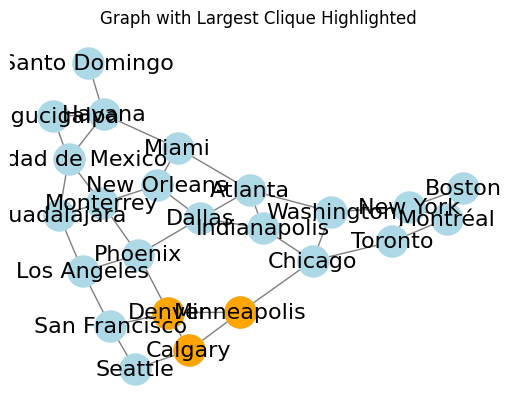

In [5]:
def plotclique(G):
    # Graph drawing
    pos = nx.spring_layout(G)  # positions for all nodes

    # Draw all nodes and edges
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
    nx.draw_networkx_edges(G, pos, alpha=0.5)

    # Highlight the nodes in the largest clique
    nx.draw_networkx_nodes(G, pos, nodelist=largest_clique, node_color='orange', node_size=500)

    # Labels for the nodes
    nx.draw_networkx_labels(G, pos, font_size=16, font_family='sans-serif')

    plt.title('Graph with Largest Clique Highlighted')
    plt.axis('off')  # Turn off the axis
    plt.show()

plotclique(Gam)

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can see that the graph has many cliques of size 3 and no one higher than that. One exemple was ploted for a clear visualisation.
  </p>
</div>

##### 2. Download the file ”pandemic_europe.graphml” on UniversiTICE, and load the graph stored in this file. This graph represent the network drawn on the board of another version of ”Pandemic” board game called ”Pandemic Hot Zone Europe”. You could find an image of this board on UniversiTICE. Find the maximum clique of this graph. Print this clique and its size

All cliques: [['Budapest', 'Minsk'], ['Budapest', 'Wien', 'Sofia'], ['Kyiv', 'Minsk', 'Moskva'], ['Kyiv', 'Bucuresti'], ['Lisboa', 'Madrid'], ['Hamburg', 'Berlin'], ['Hamburg', 'Amsterdam'], ['Hamburg', 'Kobenhavn'], ['Stockholm', 'Helsinki'], ['Stockholm', 'Warszawa', 'Kobenhavn'], ['Sofia', 'Bucuresti', 'Athina'], ['Amsterdam', 'Paris', 'London'], ['Berlin', 'Warszawa'], ['Berlin', 'Paris'], ['Berlin', 'Praha'], ['Warszawa', 'Minsk'], ['Genève', 'Wien', 'Roma'], ['Genève', 'Wien', 'Praha'], ['Genève', 'Madrid', 'Paris'], ['Dublin', 'Glasgow', 'London'], ['Helsinki', 'Moskva'], ['Athina', 'Roma']]
Largest clique: ['Budapest', 'Wien', 'Sofia']


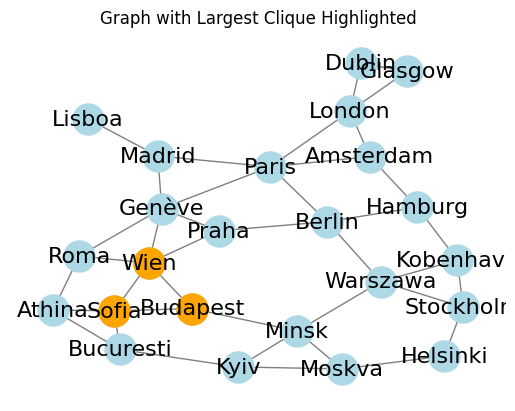

In [6]:
Geu = nx.read_graphml("pandemic_europe.graphml")

cliques = list(nx.find_cliques(Geu))
largest_clique = max(cliques, key=len)

print("All cliques:", cliques)
print("Largest clique:", largest_clique)

plotclique(Geu)

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Similarly, many cliques of size 3  were found in the european graph.
  </p>
</div>

#### 3. Determine if both graphs could be isomorphic or not using the Weisfeiler-Lehman test. If the result is positive, determine if they are isomorphic, and print the possible mapping

In [7]:
print(nx.weisfeiler_lehman_graph_hash(Gam))
print(nx.weisfeiler_lehman_graph_hash(Geu))



e80b8fe9fc7eb0590a604020b3c7e30a
2ea9ab1846469d8e72443c9c17c223f7


In [8]:
nx.is_isomorphic(Gam, Geu) 

False

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The Weifeiler Lehman Hash is different for the two graph, that strongly indicates that they are not isomorphic. The is_isomorphic function proves that assumption.
  </p>
</div>

##### 4. Extract the subgraph induced by nodes ”Wien”, ”Budapest”, ”Sofia”, ”Athina”, ”Roma” in the ”Pandemic Europe” network, and call it H_europe. Find and print the automorphism of this subgraph

In [9]:
H_europe = Geu.subgraph(['Wien', 'Budapest', 'Sofia', 'Athina', 'Roma'])

{'Wien': 'Wien', 'Budapest': 'Budapest', 'Sofia': 'Sofia', 'Roma': 'Roma', 'Athina': 'Athina'}
{'Sofia': 'Wien', 'Budapest': 'Budapest', 'Wien': 'Sofia', 'Athina': 'Roma', 'Roma': 'Athina'}


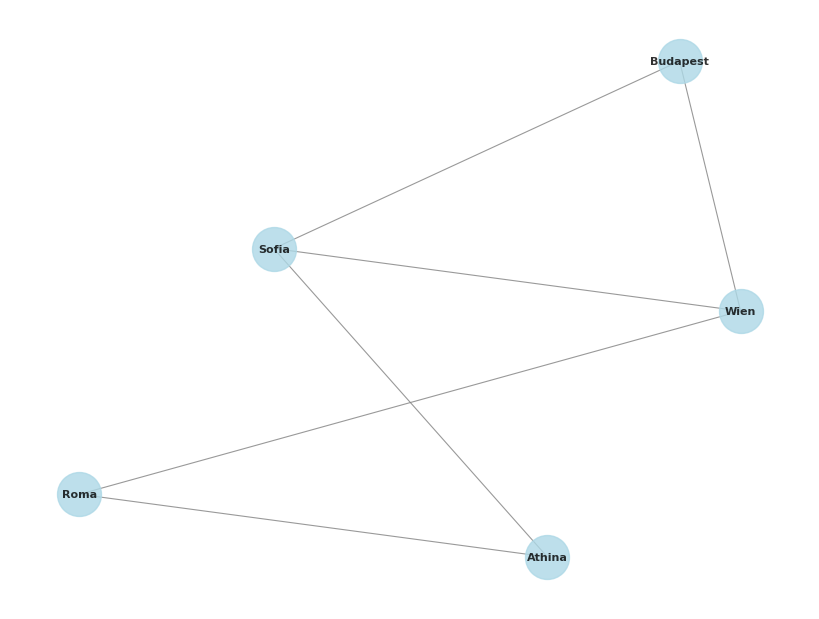

In [10]:
def automorphisms(graph):
    return list(nx.algorithms.isomorphism.GraphMatcher(graph, graph).isomorphisms_iter())

auto_list = automorphisms(H_europe)
for i in auto_list:
    print(i)

PlotGraph(H_europe)

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    As shown, there are two possible automorphisms for this graph.
  </p>
</div>

##### 5. Find all the subgraph isomorphisms of the subgraph extracted previously with the graph of the ”Pandemic North America” network. Print all the mappings provided by these isomorphisms

In [11]:
GM = nx.algorithms.isomorphism.GraphMatcher(Gam,H_europe)

for subgraph in GM.subgraph_isomorphisms_iter():
    print(subgraph)

{'Calgary': 'Wien', 'Minneapolis': 'Budapest', 'Denver': 'Sofia', 'Seattle': 'Roma', 'San Francisco': 'Athina'}
{'Denver': 'Wien', 'Minneapolis': 'Budapest', 'Calgary': 'Sofia', 'San Francisco': 'Roma', 'Seattle': 'Athina'}
{'Dallas': 'Wien', 'Indianapolis': 'Budapest', 'Atlanta': 'Sofia', 'New Orleans': 'Roma', 'Miami': 'Athina'}
{'Toronto': 'Wien', 'Montréal': 'Budapest', 'New York': 'Sofia', 'Chicago': 'Roma', 'Washington': 'Athina'}
{'New York': 'Wien', 'Montréal': 'Budapest', 'Toronto': 'Sofia', 'Washington': 'Roma', 'Chicago': 'Athina'}
{'Indianapolis': 'Wien', 'Dallas': 'Budapest', 'Atlanta': 'Sofia', 'Chicago': 'Roma', 'Washington': 'Athina'}
{'Atlanta': 'Wien', 'Indianapolis': 'Budapest', 'Dallas': 'Sofia', 'Miami': 'Roma', 'New Orleans': 'Athina'}
{'Atlanta': 'Wien', 'Dallas': 'Budapest', 'Indianapolis': 'Sofia', 'Washington': 'Roma', 'Chicago': 'Athina'}
{'Monterrey': 'Wien', 'Ciudad de Mexico': 'Budapest', 'Guadalajara': 'Sofia', 'Phoenix': 'Roma', 'Los Angeles': 'Athina'}


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We find a total of 10 possible subgraph isomorphisms in the american graph, that is, 5 pairs of automorphisms. 
  </p>
</div>

##### 6. Extract one of the subraphs of the ”Pandemic North America” network found as isomorphic in the previous question, and call it H_usa. Then verify the relation AH_europe = P.AH_usa.P T between the adjacency matrices of both graphs H_europe and H_usa, P is a permutation matrix determine thanks to a mapping founded at the previous question.

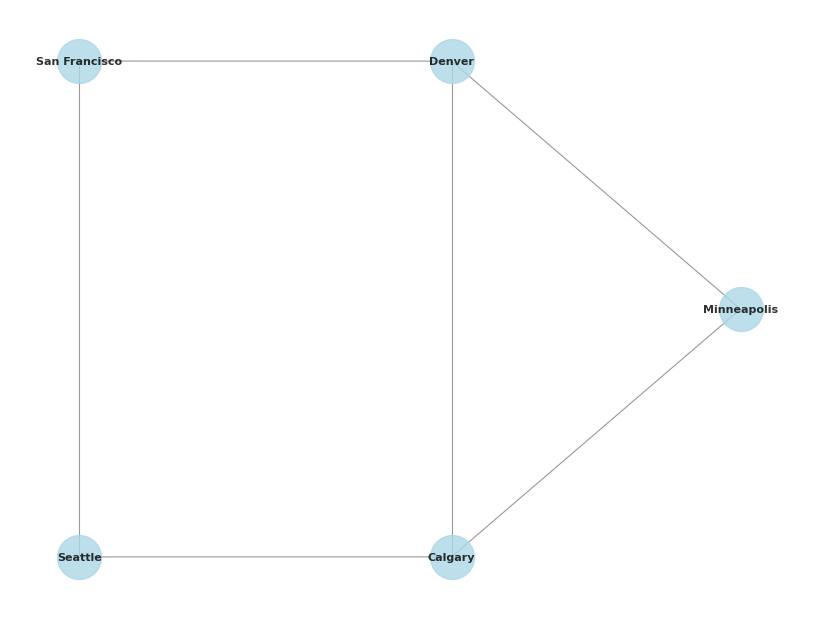

In [12]:
nodes = list(GM.subgraph_isomorphisms_iter())[0].keys()

H_usa = Gam.subgraph(nodes)

PlotGraph(H_usa)

In [17]:
# Create consistent node orderings
first_mapping = list(GM.subgraph_isomorphisms_iter())[0] # == nodes
nodes_usa = list(first_mapping.keys())
nodes_europe = [first_mapping[n] for n in nodes_usa]

# Get adjacency matrices in numpy form
A_usa = nx.to_numpy_array(H_usa, nodelist=nodes_usa, dtype=int)
A_europe = nx.to_numpy_array(H_europe, nodelist=nodes_europe, dtype=int)


In [19]:
n = len(nodes_usa)
P = np.zeros((n, n), dtype=int)

for i, usa_node in enumerate(nodes_usa):
    europe_node = first_mapping[usa_node]
    j = nodes_europe.index(europe_node)
    P[i, j] = 1

In [ ]:
lhs = A_europe
rhs = P @ A_usa @ P.T

# Check equality
print("Are the matrices equal?", np.array_equal(lhs, rhs))


Are the matrices equal? True
